In [25]:
import pandas as pd
df=pd.read_csv('c:/data/ozone/ozone.csv')
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


In [26]:
X=df[['Solar.R','Wind','Temp']]
y=df['Ozone']

In [27]:
print(df[['Solar.R','Wind','Temp','Ozone']].isna().sum())

Solar.R     7
Wind        0
Temp        0
Ozone      37
dtype: int64


In [28]:
df_clean = df[['Solar.R','Wind','Temp','Ozone']].dropna()

X = df_clean[['Solar.R','Wind','Temp']]
y = df_clean['Ozone']

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=7)

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(len(X_train.columns),)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(2, activation='relu'),
    Dense(1)
])

model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mse','mae']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

<Axes: >

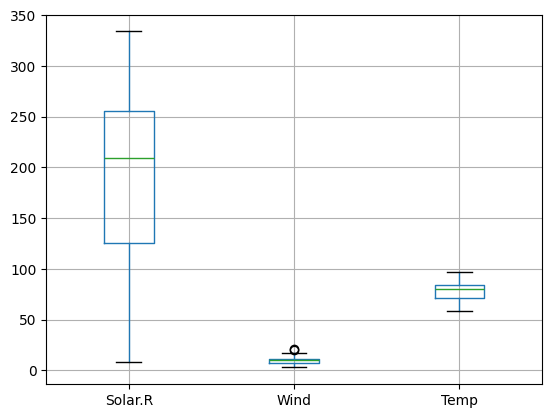

In [31]:
X_train.boxplot()

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

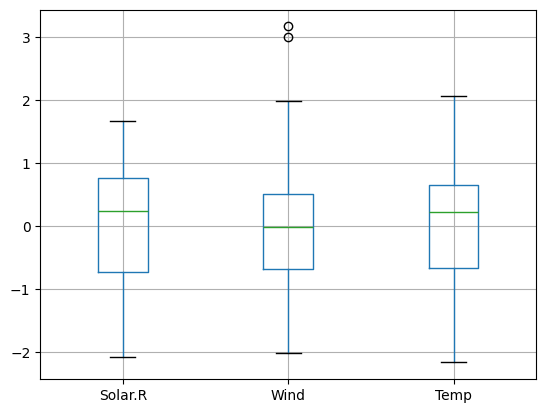

In [34]:
import matplotlib.pyplot as plt
X_train_scaled.boxplot()
plt.show()

In [35]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=50)
hist=model.fit(X_train_scaled,y_train,epochs=500,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 3010.7856 - mae: 42.9782 - mse: 3010.7856 - val_loss: 2295.2649 - val_mae: 40.3665 - val_mse: 2295.2649
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3010.2529 - mae: 42.9710 - mse: 3010.2529 - val_loss: 2294.6829 - val_mae: 40.3579 - val_mse: 2294.6829
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3009.7341 - mae: 42.9639 - mse: 3009.7341 - val_loss: 2294.1094 - val_mae: 40.3494 - val_mse: 2294.1094
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3009.2043 - mae: 42.9568 - mse: 3009.2043 - val_loss: 2293.5430 - val_mae: 40.3413 - val_mse: 2293.5430
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3008.6736 - mae: 42.9498 - mse: 3008.6736 - val_loss: 2292.9736 - val_mae: 40.3331 - val_mse: 2292.9736
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3008.1421 - mae: 42.9428 - mse: 3008.1421 - val_loss: 2292.4189 - val_mae: 40.3252 - val_mse: 2292.4189
Epoch 7/500
3/3 ━━━━━━━━━━━━

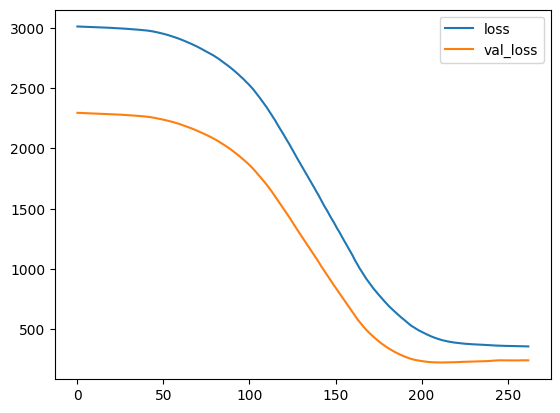

In [36]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

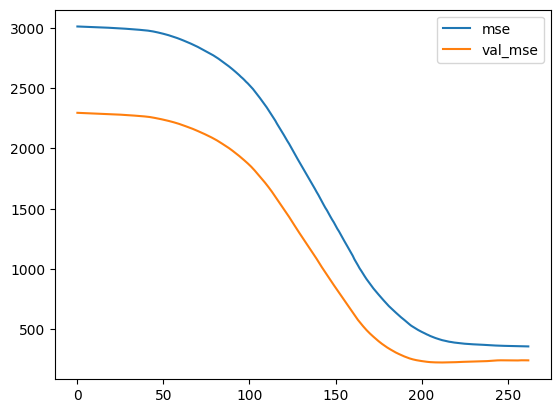

In [37]:
plt.plot(hist.history['mse'])
plt.plot(hist.history['val_mse'])
plt.legend(['mse','val_mse'])
plt.show()

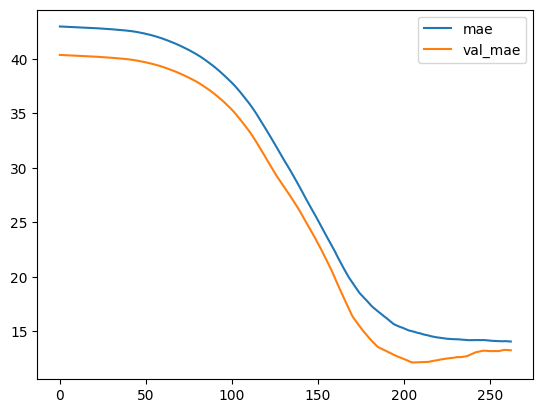

In [38]:
plt.show()
plt.plot(hist.history['mae'])
plt.plot(hist.history['val_mae'])
plt.legend(['mae', 'val_mae'])
plt.show()

In [39]:
scores = model.evaluate(X_train_scaled,y_train)
print(scores)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 335.3897 - mae: 13.8794 - mse: 335.3897
[335.3896789550781, 335.3896789550781, 13.879412651062012]


In [40]:
from sklearn.metrics import r2_score
pred = model.predict(X_test_scaled)
r2_score(y_test,pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


0.7672939961161622